In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

# 1. Setup & Mount
drive.mount('/content/drive')
base_path = '/content/drive/My Drive/e_commerce_database/'

orders = pd.read_csv(os.path.join(base_path, 'orders.csv'))
orders['OrderDate'] = pd.to_datetime(orders['OrderDate'])

# 2. Resample data into daily sales volume
daily_sales = orders.groupby(orders['OrderDate'].dt.date)['Quantity'].sum().reset_index()
daily_sales['OrderDate'] = pd.to_datetime(daily_sales['OrderDate'])
daily_sales.set_index('OrderDate', inplace=True)

print("Daily Sales Time Series Ready:")
daily_sales.head()

Mounted at /content/drive
Daily Sales Time Series Ready:


,Quantity
OrderDate,
2024-01-01,98.0
2024-01-02,85.0
2024-01-03,99.0
2024-01-04,163.0
2024-01-05,112.0


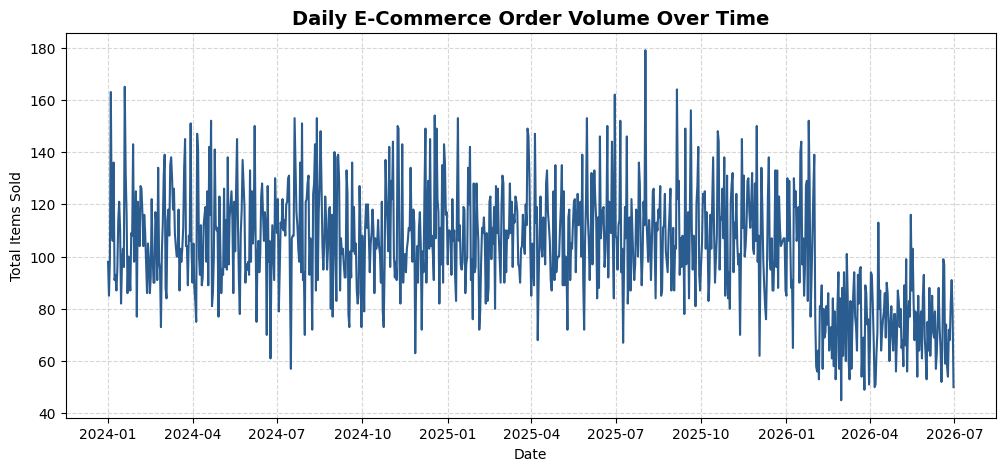

In [2]:
# Plot Daily Sales Trend
plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales['Quantity'], color='#2b5c8f', linewidth=1.5)
plt.title('Daily E-Commerce Order Volume Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Items Sold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Phase 1: Time-Series Decomposition & Moving Averages
Decomposing the daily order volume into Trend, Seasonality, and Residual components, and computing rolling averages to smooth out daily noise.

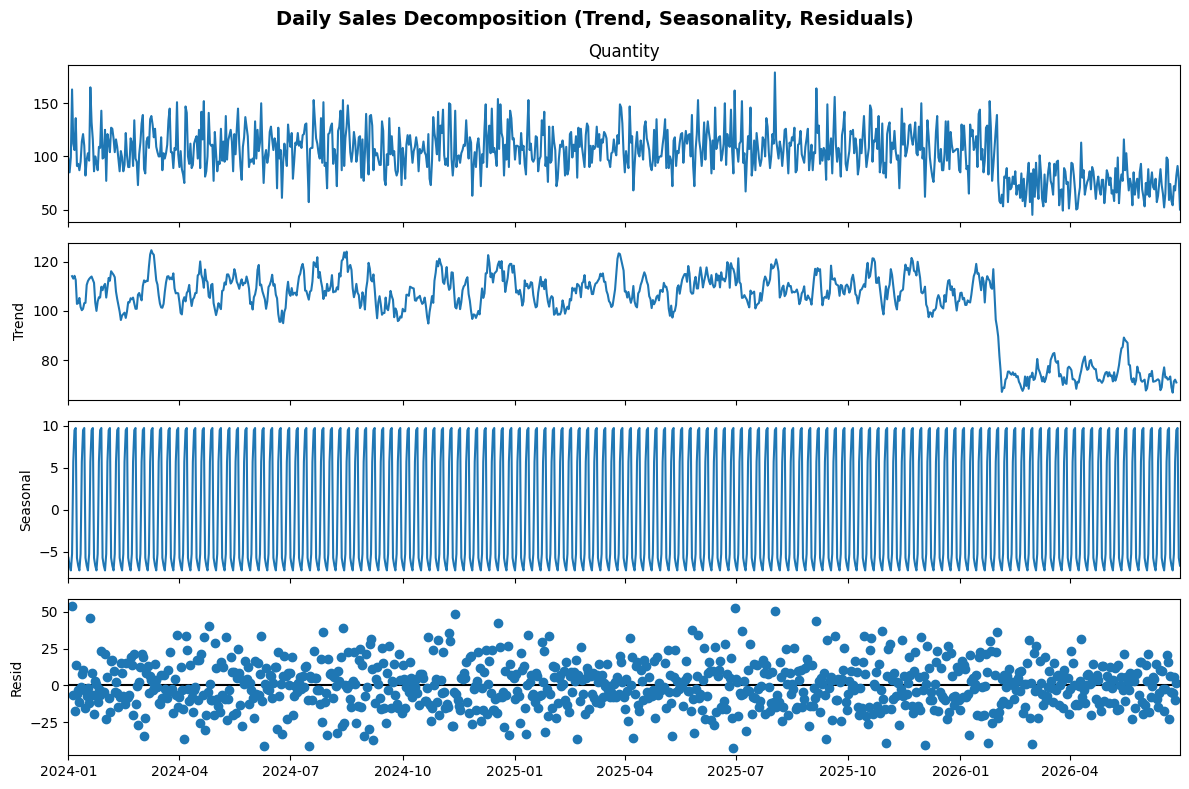

In [3]:
import statsmodels.api as sm

# 1. Decompose daily sales into Trend, Seasonality, and Residuals
# Adjust period parameter based on your dataset span (e.g., period=7 for weekly seasonality)
decomposition = sm.tsa.seasonal_decompose(daily_sales['Quantity'], model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Daily Sales Decomposition (Trend, Seasonality, Residuals)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

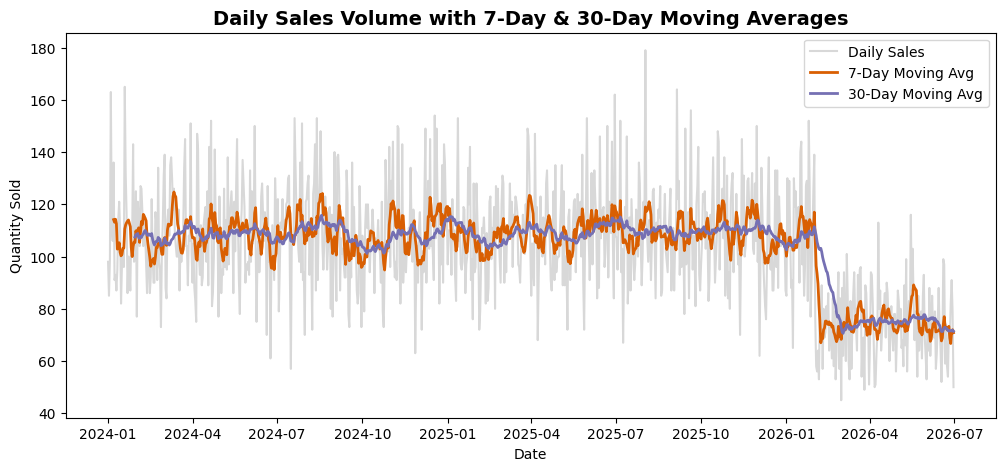

In [4]:
# 2. Add 7-day and 30-day Moving Averages to capture short & long term trends
daily_sales['7_Day_MA'] = daily_sales['Quantity'].rolling(window=7).mean()
daily_sales['30_Day_MA'] = daily_sales['Quantity'].rolling(window=30).mean()

plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales['Quantity'], label='Daily Sales', alpha=0.3, color='gray')
plt.plot(daily_sales.index, daily_sales['7_Day_MA'], label='7-Day Moving Avg', color='#d95f02', linewidth=2)
plt.plot(daily_sales.index, daily_sales['30_Day_MA'], label='30-Day Moving Avg', color='#7570b3', linewidth=2)

plt.title('Daily Sales Volume with 7-Day & 30-Day Moving Averages', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')
plt.legend()
plt.show()

# Phase 2: Train-Test Split & Forecasting Model
Splitting the time-series into training and validation sets to build an Exponential Smoothing (Holt-Winters) forecasting model.

In [5]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Train-Test Split (Reserve last 30 days for testing)
test_days = 30
train = daily_sales['Quantity'][:-test_days]
test = daily_sales['Quantity'][-test_days:]

# 2. Fit Exponential Smoothing Model with weekly seasonality
model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit()

# 3. Forecast for the test period duration
predictions = model.forecast(steps=test_days)

# 4. Evaluate Forecast Accuracy
rmse = np.sqrt(mean_squared_error(test, predictions))
mae = mean_absolute_error(test, predictions)

print(f"--- Forecast Performance Metrics ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Error (MAE):       {mae:.2f}")

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


--- Forecast Performance Metrics ---
Root Mean Squared Error (RMSE): 11.59
Mean Absolute Error (MAE):       9.72


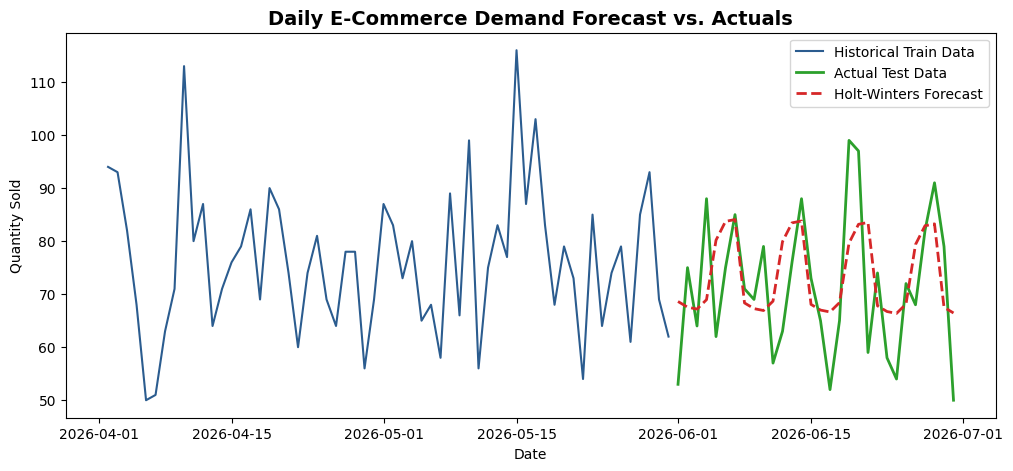

In [6]:
# Visualize Actual vs. Forecasted Sales
plt.figure(figsize=(12, 5))
plt.plot(train.index[-60:], train[-60:], label='Historical Train Data', color='#2b5c8f')
plt.plot(test.index, test, label='Actual Test Data', color='#2ca02c', linewidth=2)
plt.plot(test.index, predictions, label='Holt-Winters Forecast', color='#d62728', linestyle='--', linewidth=2)

plt.title('Daily E-Commerce Demand Forecast vs. Actuals', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Quantity Sold')
plt.legend()
plt.show()

# Phase 3: Future Horizon Forecasting & Business Insights
Generating an out-of-sample forecast for the next 30 days and translating time-series results into actionable supply chain recommendations.

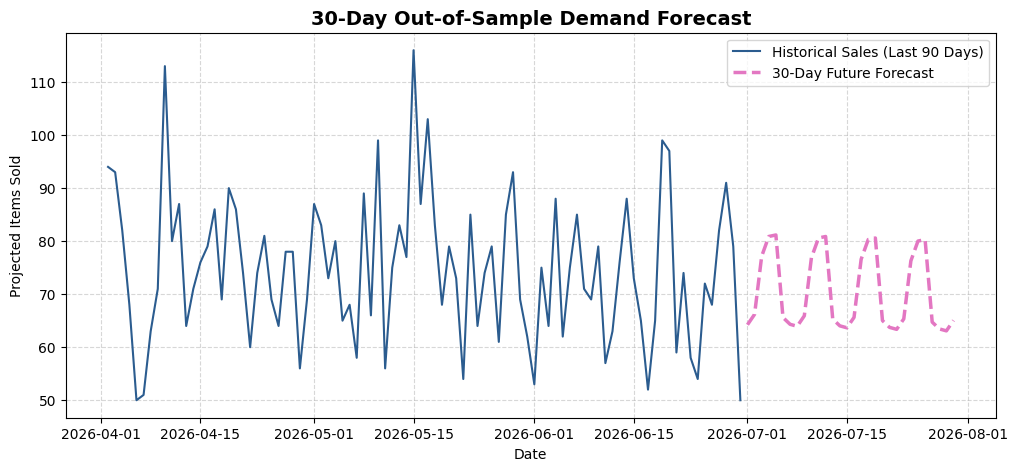

In [7]:
# 1. Refit model on the ENTIRE dataset (Train + Test)
daily_sales_clean = daily_sales.asfreq('D')  # Explicitly set daily frequency to clear warnings
final_model = ExponentialSmoothing(
    daily_sales_clean['Quantity'],
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit()

# 2. Forecast 30 days into the future
future_days = 30
future_forecast = final_model.forecast(steps=future_days)

# 3. Visualize historical data along with 30-day future projections
plt.figure(figsize=(12, 5))
plt.plot(daily_sales_clean.index[-90:], daily_sales_clean['Quantity'][-90:], label='Historical Sales (Last 90 Days)', color='#2b5c8f')
plt.plot(future_forecast.index, future_forecast, label='30-Day Future Forecast', color='#e377c2', linestyle='--', linewidth=2.5)

plt.title('30-Day Out-of-Sample Demand Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Projected Items Sold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Executive Summary & Demand Planning Recommendations

### Modeling Summary:
* **Algorithm:** Holt-Winters Exponential Smoothing (Additive Trend & Weekly Seasonality)
* **Validation Performance:** RMSE = 11.59 | MAE = 9.72
* **Pattern Analysis:** Clear 7-day weekly purchasing cycles identified during decomposition, showing demand peaks aligned with weekend order patterns.

### Key Supply Chain Takeaways:
1. **Safety Stock Buffer:** Maintain a minimum safety stock buffer of ~12 units above forecasted averages to account for the model's RMSE variance.
2. **Weekly Replenishment:** Restock inventory ahead of weekly demand peaks identified in the seasonality decomposition to avoid stockouts.
3. **Automated Procurement:** Integrate out-of-sample forecast predictions into operational purchase order triggers for inventory automation.